In [1]:
# 設定nb頁面佔滿瀏覽器寬度
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>")) # ex: width:1200px

In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.166 🚀 Python-3.10.12 torch-2.7.0+cu126 CUDA:0 (Tesla V100-SXM2-32GB, 32501MiB)
Setup complete ✅ (36 CPUs, 754.3 GB RAM, 0.0/100.0 GB disk)


In [3]:
!sudo pip install ensemble-boxes

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip


#### 1.設置環境

從畫面右上角確認有使用到GPU

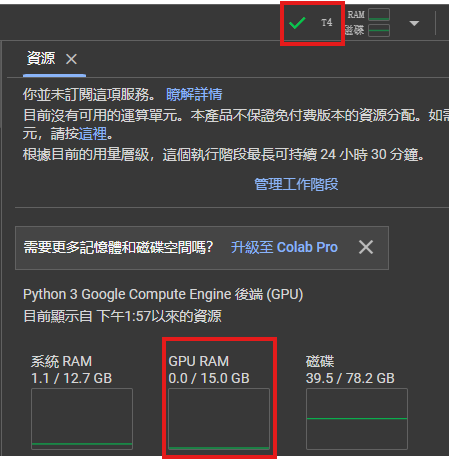

如果沒連到的話請切換到GPU

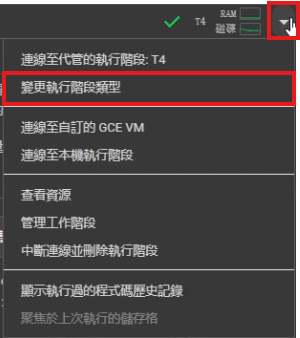
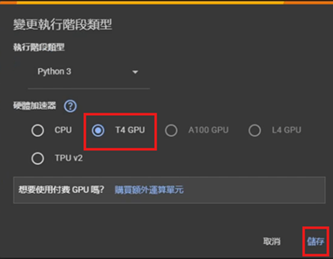

Colab區塊左方有綠色勾代表執行完成且成功 image.png


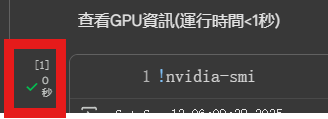

區塊左方有圈在轉代表執行中 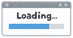

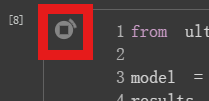

區塊左方有紅色驚嘆號代表運行錯誤 image.png

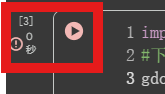

查看GPU資訊(運行時間<1秒) image.png

In [1]:
!nvidia-smi

Fri Oct  3 22:43:24 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.161.08             Driver Version: 535.161.08   CUDA Version: 12.4     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla V100-SXM2-32GB           On  | 00000000:DB:00.0 Off |                    0 |
| N/A   29C    P0              56W / 300W |    967MiB / 32768MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

確保不會出現編碼錯誤(運行時間<1秒) image.png

In [1]:
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding

下載YOLOv12套件(運行時間12秒) image.png

In [2]:
# !pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.166 🚀 Python-3.10.12 torch-2.7.0+cu126 CUDA:0 (Tesla V100-SXM2-32GB, 32501MiB)
Setup complete ✅ (36 CPUs, 754.3 GB RAM, 0.8/100.0 GB disk)


 #### 2. 上傳資料集

將testing_image.zip上傳至個人的Google雲端硬碟

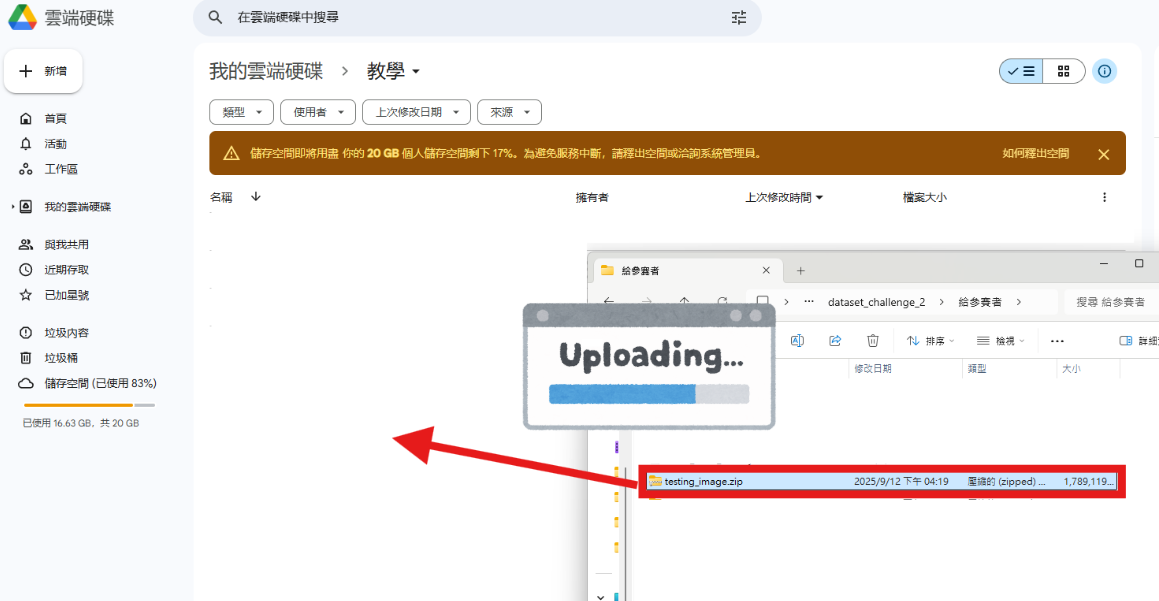

更改testing_image.zip檔案權限 image.png
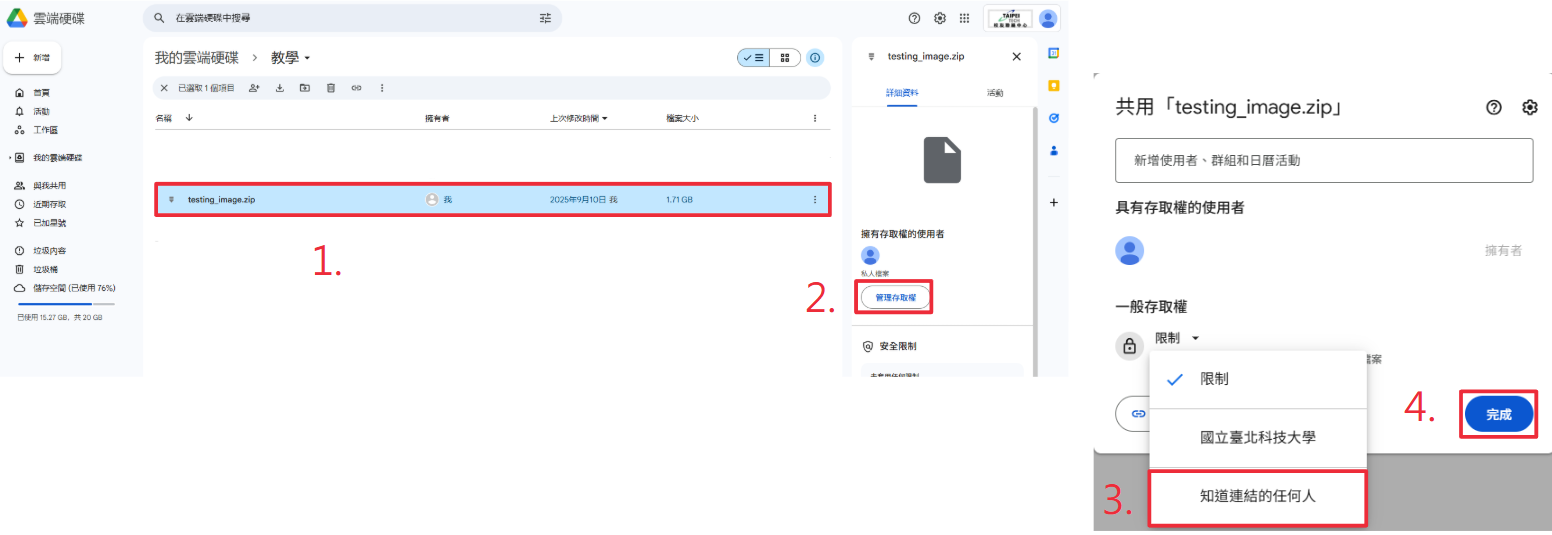

取得雲端資料下載連結(下方程式需要用到)

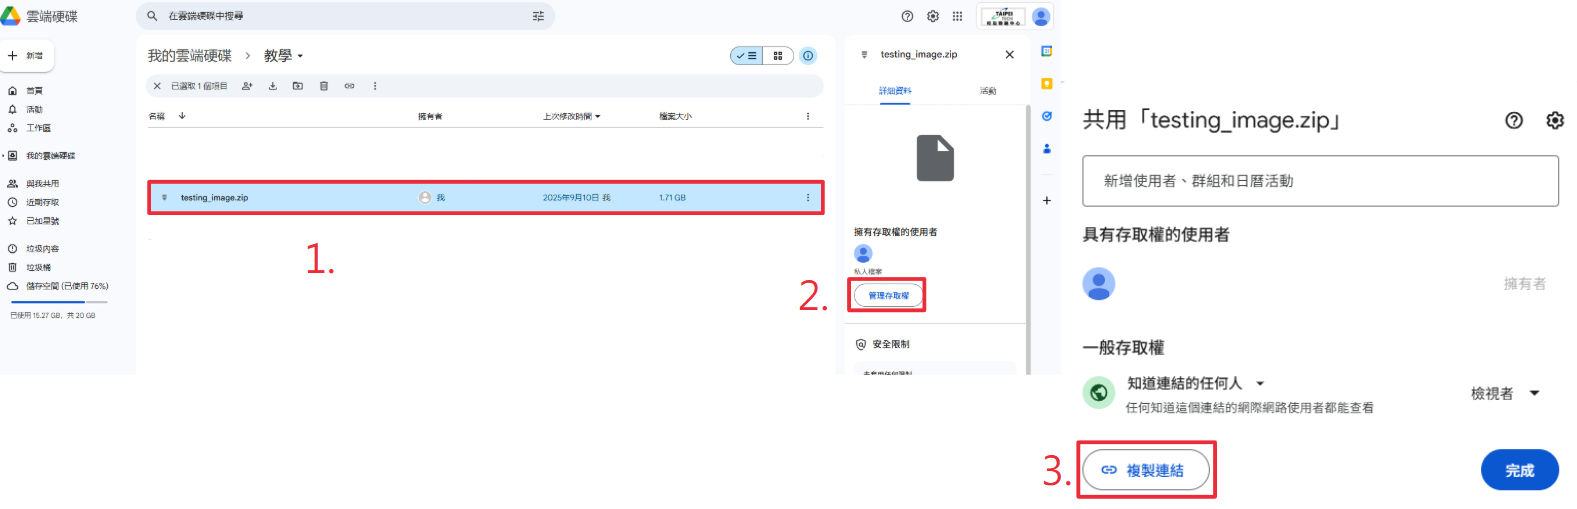

將剛剛取得的網址透過下方網址轉換成直接下載的格式


https://sites.google.com/view/twdrivefromdownload/%E7%B9%81%E9%AB%94%E4%B8%AD%E6%96%87traditional-chinese?authuser=0


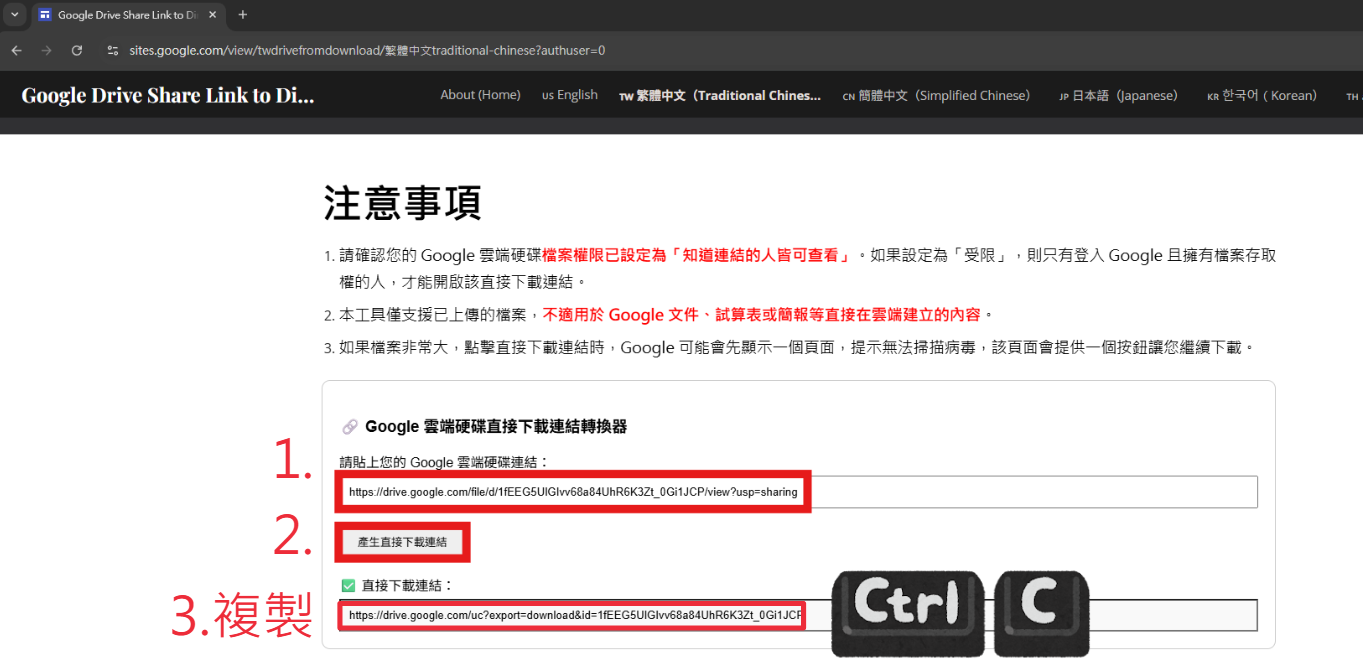

透過上面方法更改下方程式的網址(執行時間<1分鐘) image.png


 *請自行上傳雲端替換成自己的連結，此範例連結雖然與最初競賽資料集相同，但不保證會更新且隨時有可能會刪除!!!

In [ ]:
#下載資料集
import gdown
import os
!mkdir ./datasets
!mkdir ./datasets/test
gdown.download("https://drive.google.com/uc?export=download&id=1jHDK0YWhLOGG2pxikG1IymEoRyFlJctN","/content/datasets/testing.zip")
!unzip '/content/datasets/testing' -d '/content/datasets/test/tmp'

mkdir: cannot create directory ‘./datasets’: File exists
mkdir: cannot create directory ‘./datasets/test’: File exists


Downloading...
From (original): https://drive.google.com/uc?export=download&id=1jHDK0YWhLOGG2pxikG1IymEoRyFlJctN
From (redirected): https://drive.google.com/uc?export=download&id=1jHDK0YWhLOGG2pxikG1IymEoRyFlJctN&confirm=t&uuid=8acc47c6-b4ca-4944-abc7-49c46b799f56
To: /content/datasets/testing.zip
100%|██████████| 1.83G/1.83G [00:28<00:00, 63.7MB/s]


串流輸出內容已截斷至最後 5000 行。
  inflating: /content/datasets/test/tmp/patient0086/patient0086_0063.png  
  inflating: /content/datasets/test/tmp/patient0086/patient0086_0064.png  
  inflating: /content/datasets/test/tmp/patient0086/patient0086_0065.png  
  inflating: /content/datasets/test/tmp/patient0086/patient0086_0066.png  
  inflating: /content/datasets/test/tmp/patient0086/patient0086_0067.png  
  inflating: /content/datasets/test/tmp/patient0086/patient0086_0068.png  
  inflating: /content/datasets/test/tmp/patient0086/patient0086_0069.png  
  inflating: /content/datasets/test/tmp/patient0086/patient0086_0070.png  
  inflating: /content/datasets/test/tmp/patient0086/patient0086_0071.png  
  inflating: /content/datasets/test/tmp/patient0086/patient0086_0072.png  
  inflating: /content/datasets/test/tmp/patient0086/patient0086_0073.png  
  inflating: /content/datasets/test/tmp/patient0086/patient0086_0074.png  
  inflating: /content/datasets/test/tmp/patient0086/patient0086_0075.png  
  in

因為本競賽Testing資料集有16620張圖片，如果全部一起預測Colab的RAM會不足，所以將Testing圖片分成兩次做預測

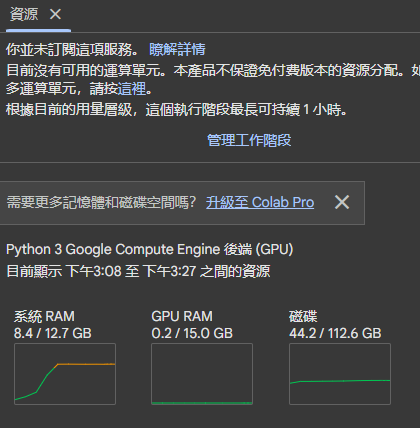

移動圖片位置(透過下方程式)


一半的圖片移至imges1資料夾，另一半移至imges2資料夾

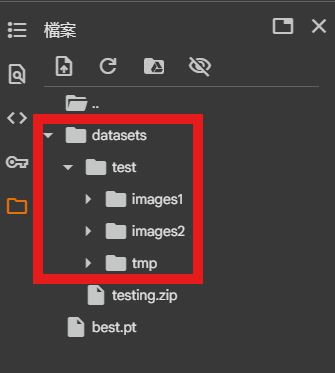

In [ ]:
import os
import shutil

src_root = "/content/datasets/test/tmp"
dst_root1 = "/content/datasets/test/images1"
dst_root2 = "/content/datasets/test/images2"

os.makedirs(dst_root1, exist_ok=True)
os.makedirs(dst_root2, exist_ok=True)

# 收集所有圖片路徑
all_files = []
for patient_folder in os.listdir(src_root):
    patient_path = os.path.join(src_root, patient_folder)
    if os.path.isdir(patient_path) and patient_folder.startswith("patient"):
        for fname in os.listdir(patient_path):
            if fname.endswith(".png"):
                all_files.append(os.path.join(patient_path, fname))

# 按照檔名排序，方便重現結果
all_files.sort()

# 計算一半
half = len(all_files) // 2

# 前半移到 images1/
for f in all_files[:half]:
    dst_file = os.path.join(dst_root1, os.path.basename(f))
    shutil.move(f, dst_file)

# 後半移到 images2/
for f in all_files[half:]:
    dst_file = os.path.join(dst_root2, os.path.basename(f))
    shutil.move(f, dst_file)

print(f"完成移動！總共 {len(all_files)} 張，前半 {half} 張放到 images1/，後半 {len(all_files)-half} 張放到 images2/")

In [ ]:
print('測試集圖片數量 : ',len(os.listdir("./datasets/test/images1"))+len(os.listdir("./datasets/test/images2")))

### 本地版的移動兩份

In [8]:
import os
import shutil

src_root = "datasets/testing_image"
dst_root1 = "datasets/test/images1"
dst_root2 = "datasets/test/images2"

os.makedirs(dst_root1, exist_ok=True)
os.makedirs(dst_root2, exist_ok=True)

# 收集所有圖片路徑
all_files = []
for patient_folder in os.listdir(src_root):
    patient_path = os.path.join(src_root, patient_folder)
    if os.path.isdir(patient_path) and patient_folder.startswith("patient"):
        for fname in os.listdir(patient_path):
            if fname.endswith(".png"):
                all_files.append(os.path.join(patient_path, fname))

# 按照檔名排序，方便重現結果
all_files.sort()

# 計算一半
half = len(all_files) // 2

# 前半移到 images1/
for f in all_files[:half]:
    dst_file = os.path.join(dst_root1, os.path.basename(f))
    shutil.move(f, dst_file
    #shutil.cp(f, dst_file)

# 後半移到 images2/
for f in all_files[half:]:
    dst_file = os.path.join(dst_root2, os.path.basename(f))
    shutil.move(f, dst_file)
    #shutil.cp(f, dst_file)

print(f"完成移動！總共 {len(all_files)} 張，前半 {half} 張放到 images1/，後半 {len(all_files)-half} 張放到 images2/")

完成移動！總共 16620 張，前半 8310 張放到 images1/，後半 8310 張放到 images2/


In [2]:
# 50個病人資料夾

print('50個病人資料夾數量 : ',len(os.listdir("./datasets/testing_image")))

50個病人資料夾數量 :  50


In [3]:
print('測試集圖片數量 : ',len(os.listdir("./datasets/test/images1"))+len(os.listdir("./datasets/test/images2")))

測試集圖片數量 :  16620


#### 3. Predict

下載模型權重檔(此權重檔為baseline提供的模型，參賽者可替換成自行訓練的模型檔)

In [ ]:
#自行上傳權重檔請註解掉下方程式
gdown.download("https://drive.google.com/uc?export=download&id=1cyV2eWcJYJcvWnc56L_zp1Lky3p9Yign","/content/best.pt")

Downloading...
From: https://drive.google.com/uc?export=download&id=1cyV2eWcJYJcvWnc56L_zp1Lky3p9Yign
To: /content/best.pt
100%|██████████| 5.51M/5.51M [00:00<00:00, 75.2MB/s]


'/content/best.pt'

使用自行訓練模型可透過拖移方式上傳至Colab

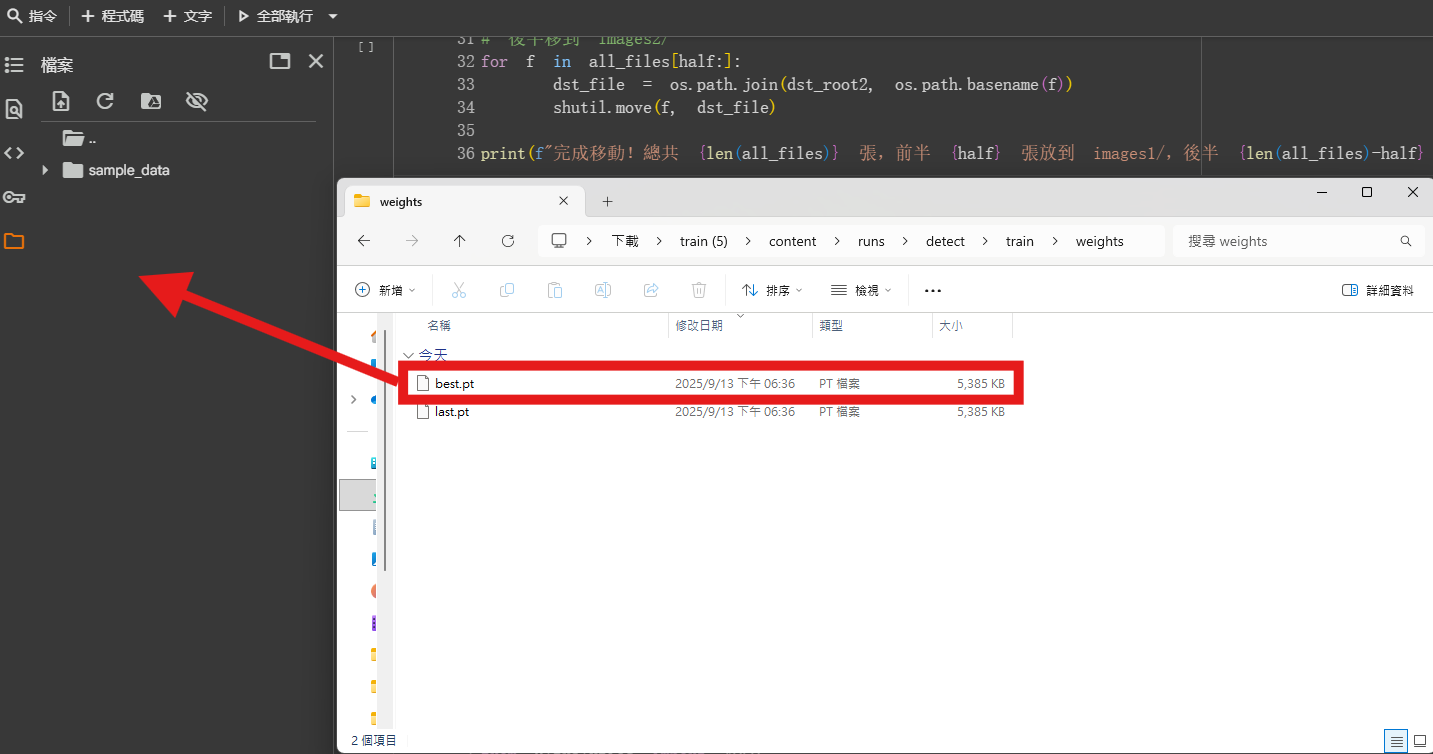

使用訓練過模型進行預測前半部分圖片(執行時間3分鐘)

- run6, 全部空txt都一起訓練
- run7, v12x, 100epoch, all empty txt,

In [ ]:
# %%time

# from ultralytics import YOLO

# # model = YOLO('/content/best.pt')
# # model = YOLO('runs/detect/train6/weights/best.pt')
# # model = YOLO('runs/detect/train7/weights/best.pt')
# # model = YOLO('runs/detect/train8/weights/best.pt')
# # model = YOLO('runs/detect/train9/weights/best.pt')

# # model = YOLO('runs/detect/train10/weights/best.pt')

# # model = YOLO('runs/detect/train11/weights/best.pt')

# # model = YOLO('runs/detect/train12/weights/best.pt')
# model = YOLO('runs/detect/train15/weights/best.pt')
# results = model.predict(source="./datasets/test/images1/",
#               save=True,
#               imgsz=640,
#               #device=0
#               )

In [12]:
12x Wall time: 5min 3s

SyntaxError: invalid decimal literal (2622660358.py, line 1)

predict資料夾內**有圖片代表預測完成**


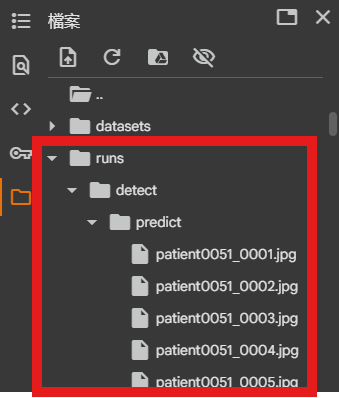

其中一張預測結果

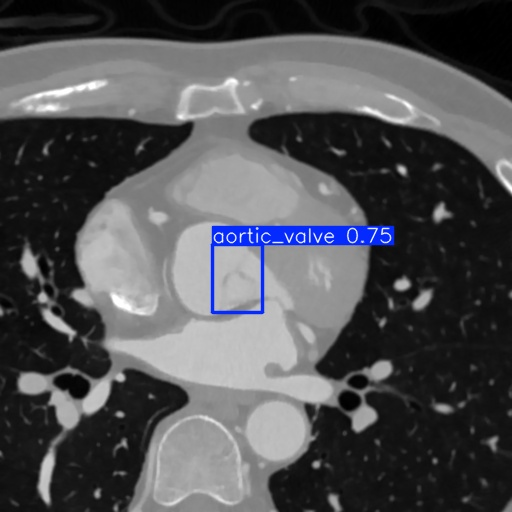

In [3]:
# from IPython.display import Image

# Image(filename='runs/detect/predict3/patient0051_0260.jpg', height=600)

預測數量

In [4]:
# print(len(results))

8310


取得預測結果的資訊

想取得更多資訊可參考官方說明
https://docs.ultralytics.com/zh/modes/predict/#boxes

In [5]:
# print('預測類別 : ',results[260].boxes.cls[0].item())
# print('預測信心分數 : ',results[260].boxes.conf[0].item())
# print('預測框座標 : ',results[260].boxes.xyxy[0].tolist())

預測類別 :  0.0
預測信心分數 :  0.7920070886611938
預測框座標 :  [212.33482360839844, 245.3293914794922, 261.35546875, 311.0438537597656]


將偵測框數值寫進.txt檔

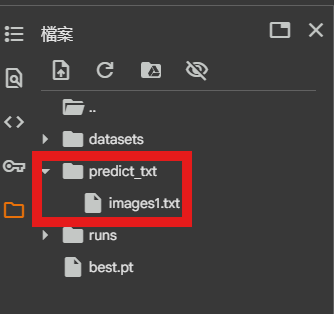

In [11]:

# mk dir if not exist!
# !mkdir ./predict_txt/

output_file = open('./predict_txt/images1.txt', 'w')
for i in range(len(results)):
    # 取得圖片檔名（不含副檔名）
    filename = results[i].path.split('/')[-1].split('.png')[0]

    # 取得預測框數量
    boxes = results[i].boxes
    box_num = len(boxes.cls.tolist())

    # 如果有預測框
    if box_num > 0:
        for j in range(box_num):
            # 提取資訊
            label = int(boxes.cls[j].item())  # 類別
            conf = boxes.conf[j].item()       # 信心度
            x1, y1, x2, y2 = boxes.xyxy[j].tolist()  # 邊界框座標

            # 建立一行資料
            line = f"{filename} {label} {conf:.4f} {int(x1)} {int(y1)} {int(x2)} {int(y2)}\n"
            output_file.write(line)

# 關閉輸出檔案
output_file.close()


釋放記憶體

因為Colab RAM不會自動釋放，所以透過程式釋放


In [18]:
import torch ,gc

# 刪除大型變數
del boxes,all_files,results
gc.collect()
torch.cuda.empty_cache()

NameError: name 'all_files' is not defined

預測後半圖片(執行時間3分鐘)

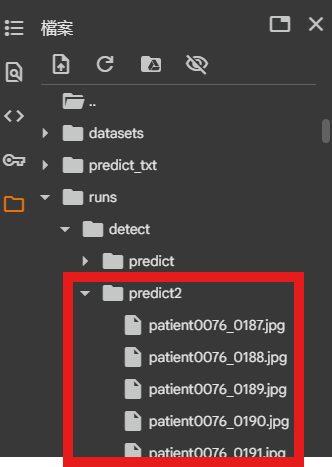

In [ ]:
%%time

"""
12x, 16620/2張
Wall time: 5min 3s
"""


# from ultralytics import YOLO

# # model = YOLO('/content/best.pt')
# # model = YOLO('runs/detect/train6/weights/best.pt')
# # model = YOLO('runs/detect/train7/weights/best.pt')
# # model = YOLO('runs/detect/train8/weights/best.pt')
# # model = YOLO('runs/detect/train9/weights/best.pt')

# # model = YOLO('runs/detect/train10/weights/best.pt')

# # model = YOLO('runs/detect/train11/weights/best.pt')

# # model = YOLO('runs/detect/train12/weights/best.pt')
# model = YOLO('runs/detect/train15/weights/best.pt')
# results = model.predict(source="./datasets/test/images2/",
#               save=True,
#               imgsz=640,
#               device=0
#               )

將後半部分偵測框數值寫進.txt檔

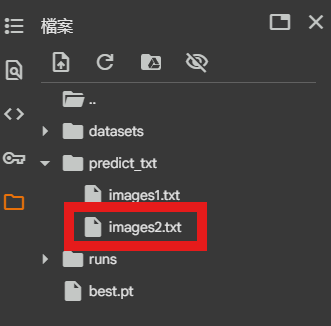

In [13]:
output_file = open('./predict_txt/images2.txt', 'w')
for i in range(len(results)):
    # 取得圖片檔名（不含副檔名）
    filename = results[i].path.split('/')[-1].split('.png')[0]

    # 取得預測框數量
    boxes = results[i].boxes
    box_num = len(boxes.cls.tolist())

    # 如果有預測框
    if box_num > 0:
        for j in range(box_num):
            # 提取資訊
            label = int(boxes.cls[j].item())  # 類別
            conf = boxes.conf[j].item()       # 信心度
            x1, y1, x2, y2 = boxes.xyxy[j].tolist()  # 邊界框座標

            # 建立一行資料
            line = f"{filename} {label} {conf:.4f} {int(x1)} {int(y1)} {int(x2)} {int(y2)}\n"
            output_file.write(line)

# 關閉輸出檔案
output_file.close()


合併兩個.txt

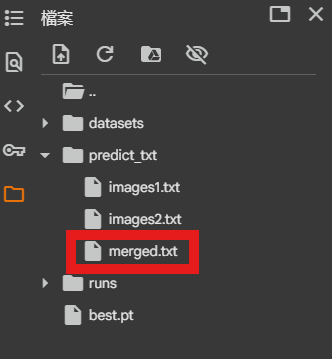

In [14]:
import os 

file1 = "./predict_txt/images1.txt"
file2 = "./predict_txt/images2.txt"
output = "./predict_txt/run15_g8v2_512_merged.txt"

with open(output, "w", encoding="utf-8") as fout:
    for f in [file1, file2]:
        if os.path.exists(f):
            with open(f, "r", encoding="utf-8") as fin:
                fout.writelines(fin.readlines())

print(f"合併完成 -> {output}")


合併完成 -> ./predict_txt/run15_512_merged.txt


下載競賽提交txt  image.png

# ⬆️上面都不用執行⬆️

# KFold prediction
- 2025-1-19
 - merged test/image1, test/image2 to test_all/
 - runs/detect/{ K2 L3 K4 K5 }

In [ ]:
%%time

from ultralytics import YOLO

# K-Fold number v12x #
# Fold = "K4-600e"
# Fold = "K5-600e-v2"
# Fold = "K5-600e-v3"
# Fold = "K2-2"

# K-Fold number v12x + TTA #
# Fold = "K3-600e" # TTA
# Fold = "K2-2" # 



## V9e ##
# Fold = "V9e/V9e-K5"
# Fold = "V9e/V9e-K2"
Fold = "V9e/V9e-K1"


run_ta=True

if run_ta:
    run_ta=True
    TTA = "-ta"
else:
    run_ta=False
    TTA = ""

print(f'run_ta={run_ta}, model={Fold}, out={TTA}')

model = YOLO(f'runs/detect/{Fold}/weights/best.pt')
results = model.predict(source="./datasets/test_all/",
              save=False, #True,
              imgsz=640,
              device=0,
#                     conf=0.5,iou,rect,half,max_det,
                    augment=run_ta, #	bool	False	Enables test-time augmentation (TTA) for predictions, potentially improving detection robustness at the cost of inference speed.
              )

In [2]:
# org~26.6ms
# tta~66.8ms

#### 其中一張預測結果

In [3]:
from IPython.display import Image

Image(filename='runs/detect/predict3/patient0051_0260.jpg', height=600)

####  預測結果

In [4]:
print('預測類別 : ',results[260].boxes.cls[0].item())
print('預測信心分數 : ',results[260].boxes.conf[0].item())
print('預測框座標 : ',results[260].boxes.xyxy[0].tolist())

In [5]:
print(len(results))

In [6]:
output_file = open(f'./predict_txt/{Fold}{TTA}.txt', 'w')


for i in range(len(results)):
    # 取得圖片檔名（不含副檔名）
    filename = results[i].path.split('/')[-1].split('.png')[0]

    # 取得預測框數量
    boxes = results[i].boxes
    box_num = len(boxes.cls.tolist())

    # 如果有預測框
    if box_num > 0:
        for j in range(box_num):
            # 提取資訊
            label = int(boxes.cls[j].item())  # 類別
            conf = boxes.conf[j].item()       # 信心度
            x1, y1, x2, y2 = boxes.xyxy[j].tolist()  # 邊界框座標

            # 建立一行資料
            line = f"{filename} {label} {conf:.4f} {int(x1)} {int(y1)} {int(x2)} {int(y2)}\n"
            output_file.write(line)

# 關閉輸出檔案
output_file.close()

print(f'Output inference reuslt to ./predict_txt/{Fold}{TTA}.txt')

# WBF
pip install ensemble-boxes numpy

您好！您提出了將 K-Fold 交叉驗證訓練出的多個 YOLO 模型結果進行 **Weighted Box Fusion (WBF)** 集成的實務問題，並提出了兩個非常關鍵的優化條件：

1.  **多數模型確認：** 只有當一張圖有**足夠數量 (自定義參數 $T$)** 的模型預測出邊界框時，才保留其預測結果。
2.  **預測統計：** 紀錄每張圖有多少模型進行了預測。

這是集成學習中提高**準確度和魯棒性**的標準做法。

以下是使用 Python 實作 **WBF 集成**的程式碼，我們將使用業界常用的 `ensemble-boxes` 函式庫來執行 WBF 演算法。

### WBF 集成實作程式碼

我們假設您的預測結果文件（`k1.txt` 到 `k5.txt`）位於一個名為 `predictions` 的資料夾中。

#### 1\. 安裝必要套件

您需要安裝 `ensemble-boxes` 函式庫來執行 WBF：

```bash
pip install ensemble-boxes numpy
```

#### 2\. Python WBF 實作程式碼


### 程式碼關鍵點與您的優化參數

1.  **資料結構與載入 (`load_predictions` 函數):**

      * 程式首先將所有 `k1.txt` 到 `k5.txt` 的預測結果讀取進來，並按照**圖片名稱**進行分類。
      * **座標歸一化 (Normalization):** WBF 函式庫要求邊界框座標必須是 $0$ 到 $1$ 之間的**歸一化值**。由於您訓練時使用 $640 \times 640$，程式假設推理也是 $640 \times 640$ 並進行了歸一化：`xmin / 640`, `ymin / 640` 等。**如果您實際推理尺寸不同，請調整 `IMAGE_SIZE` 變數。**

2.  **多數模型篩選 (您的需求 1):**

      * 在迴圈中，變數 `predicted_folds_count` 統計了有多少個模型對當前圖片有輸出（即預測結果非空）。
      * 關鍵判斷：`if predicted_folds_count < MODEL_MIN_THRESHOLD: continue`。如果預測模型數量小於您設定的 `MODEL_MIN_THRESHOLD`（預設為 3），則**直接跳過**該圖片的 WBF 過程，實現了多數模型確認的篩選邏輯。

3.  **預測統計 (您的需求 2):**

      * 程式使用 `stats_data` 列表來記錄每張圖片的 `predicted_model_count`。
      * 最終會將這些數據輸出到 **`wbf_prediction_stats.csv`** 檔案中。您可以透過分析這個 CSV 文件中每個圖片的預測模型數量分佈，來**優化調整** `MODEL_MIN_THRESHOLD` 的值，以獲得最佳的集成效果。

4.  **WBF 參數:**

      * `iou_thr` (IoU 閾值) 決定了多個框被視為來自同一物件的標準，預設 0.5 通常是一個合理的起點。
      * `weights=None`：表示您的 K5 個模型權重相同。如果您想給表現較好的 K-Fold 模型更高的權重，可以傳入一個例如 `[1.1, 1.0, 0.9, 1.05, 0.95]` 的權重列表。

In [10]:
# import os
# import numpy as np
# import pandas as pd
# from ensemble_boxes import weighted_boxes_fusion
# from collections import defaultdict

# # --- [設定參數] ---
# PREDS_DIR = './predict_txt'  # 存放 k1.txt 到 k5.txt 的資料夾路徑
# NUM_FOLDS = 5                # K-Fold 的數量，即預測文件的數量
# MODEL_MIN_THRESHOLD = 3      # 關鍵參數：每張圖最少需要多少個模型成功預測 (T)，低於此數量的預測將被篩除。
# IOU_THRESHOLD = 0.5          # WBF 演算法的 IoU 閾值
# SKIP_BOX_THRESHOLD = 0.0001  # WBF 演算法的最小置信度，低於此值的框將被忽略 (接近0即可)

# # 輸出結果文件
# OUTPUT_WBF_FILE = './wbf_ensemble_results_v1.txt'
# OUTPUT_STATS_FILE = './wbf_prediction_stats_v1.csv'

# # --- [函數定義: 讀取和轉換 YOLO 格式預測] ---

# def load_predictions(preds_dir, num_folds):
#     """
#     載入所有 K-Fold 模型的預測結果，並按圖片名稱分類。
    
#     預測結果格式轉換：
#     從 (圖片名稱, 類別, 置信度, xmin, ymin, xmax, ymax) 轉換為 WBF 所需格式。
#     注意：WBF 要求邊界框座標進行歸一化 (0 到 1000)，這裡假設座標為原始像素值。
#     """
    
#     # 這裡我們需要知道影像的尺寸，以便將像素座標轉換為 0~1 的歸一化座標
#     # 由於您在訓練時使用 imgsz=640，我們假設原始影像也被縮放到 640x640 進行推理
#     # 由於您提供的範例座標看起來像原始像素值，我們需要進行歸一化。
#     IMAGE_SIZE = 640 # YOLO 推理時的尺寸
    
#     # 儲存所有預測結果，結構: {image_name: [model_1_preds, model_2_preds, ...]}
#     all_image_preds = defaultdict(lambda: [[] for _ in range(num_folds)])

#     for k in range(1, num_folds + 1):
#         pred_file = os.path.join(preds_dir, f'K{k}.txt')
#         if not os.path.exists(pred_file):
#             print(f"警告：未找到文件 {pred_file}，將跳過。")
#             continue

#         with open(pred_file, 'r') as f:
#             for line in f:
#                 parts = line.strip().split()
#                 if len(parts) == 7:
#                     # 讀取數據
#                     image_name = parts[0]
#                     category_id = int(parts[1])  # 類別 (0)
#                     confidence = float(parts[2]) # 信心分數
#                     xmin = int(parts[3])
#                     ymin = int(parts[4])
#                     xmax = int(parts[5])
#                     ymax = int(parts[6])

#                     # 將像素座標歸一化到 0~1 範圍
#                     # WBF 函式庫要求輸入是歸一化座標
#                     normalized_box = [
#                         xmin / IMAGE_SIZE,
#                         ymin / IMAGE_SIZE,
#                         xmax / IMAGE_SIZE,
#                         ymax / IMAGE_SIZE
#                     ]

#                     # 儲存 (box, score, class)
#                     # 這裡我們假設所有類別都是 0 (心臟瓣膜)
#                     all_image_preds[image_name][k-1].append({
#                         'box': normalized_box,
#                         'score': confidence,
#                         'class': category_id
#                     })
#                 # else: 忽略格式不正確的行

#     return all_image_preds, IMAGE_SIZE

# # --- [主要執行邏輯] ---

# if __name__ == '__main__':
    
#     all_preds, img_size = load_predictions(PREDS_DIR, NUM_FOLDS)
    
#     # 儲存最終 WBF 結果
#     wbf_results = []
#     # 儲存統計數據
#     stats_data = []

#     for image_name, fold_preds_list in all_preds.items():
        
#         # 1. 收集該圖片所有模型的預測
#         boxes_list = []      # 歸一化邊界框 [xmin, ymin, xmax, ymax]
#         scores_list = []     # 置信度分數
#         labels_list = []     # 類別標籤 (都是 0)
        
#         predicted_folds_count = 0 # 紀錄有多少模型成功預測
        
#         for fold_preds in fold_preds_list:
#             if fold_preds:
#                 # 只有當該模型有預測時才納入統計
#                 predicted_folds_count += 1
                
#                 # 從字典列表中提取出框、分數和標籤
#                 boxes_list.append([p['box'] for p in fold_preds])
#                 scores_list.append([p['score'] for p in fold_preds])
#                 labels_list.append([p['class'] for p in fold_preds])

#         # 2. 統計與篩選 (滿足您的需求 2 和 1)
#         stats_data.append({
#             'image_name': image_name,
#             'predicted_model_count': predicted_folds_count
#         })
        
#         if predicted_folds_count < MODEL_MIN_THRESHOLD:
#             # 不滿足最低模型數量的閾值，篩除該圖片的預測 (需求 1)
#             continue
            
#         # 3. 執行 Weighted Box Fusion
#         # WBF 要求 boxes_list 是 ndarray 類型
        
#         # 將列表轉換為 numpy 陣列
#         all_boxes = [np.array(b) for b in boxes_list]
#         all_scores = [np.array(s) for s in scores_list]
#         all_labels = [np.array(l) for l in labels_list]
        
#         # [!!! WBF 呼叫 !!!]
#         boxes_wbf, scores_wbf, labels_wbf = weighted_boxes_fusion(
#             all_boxes,
#             all_scores,
#             all_labels,
#             weights=None,                   # 這裡可以設置每個模型的權重，None 表示權重相同
#             iou_thr=IOU_THRESHOLD,          # IoU 閾值
#             skip_box_thr=SKIP_BOX_THRESHOLD # 置信度閾值
#         )

#         # 4. 格式化 WBF 結果
#         for box, score, label in zip(boxes_wbf, scores_wbf, labels_wbf):
#             # 將歸一化座標轉換回像素座標
#             xmin = int(box[0] * img_size)
#             ymin = int(box[1] * img_size)
#             xmax = int(box[2] * img_size)
#             ymax = int(box[3] * img_size)
            
#             # 格式: 圖片名稱 類別(0) 信心分數 xmin ymin xmax ymax
#             result_line = f"{image_name} {int(label)} {score:.4f} {xmin} {ymin} {xmax} {ymax}"
#             wbf_results.append(result_line)

#     # 5. 輸出結果文件
#     with open(OUTPUT_WBF_FILE, 'w') as f:
#         f.write('\n'.join(wbf_results))
        
#     print(f"\n✅ WBF 集成結果已儲存至：{OUTPUT_WBF_FILE}")
#     print(f"   總共輸出了 {len(wbf_results)} 個邊界框。")

#     # 6. 輸出統計數據 (需求 2)
#     stats_df = pd.DataFrame(stats_data)
#     stats_df.to_csv(OUTPUT_STATS_FILE, index=False)
    
#     print(f"✅ 預測統計數據已儲存至：{OUTPUT_STATS_FILE}")
#     print(f"   最低模型閾值 (MODEL_MIN_THRESHOLD) 設定為 {MODEL_MIN_THRESHOLD}。")
#     print(f"   您可以分析統計數據來調整此閾值。")


✅ WBF 集成結果已儲存至：./wbf_ensemble_results_v1.txt
   總共輸出了 3141 個邊界框。
✅ 預測統計數據已儲存至：./wbf_prediction_stats_v1.csv
   最低模型閾值 (MODEL_MIN_THRESHOLD) 設定為 3。
   您可以分析統計數據來調整此閾值。


In [7]:
import os
import numpy as np
import pandas as pd
from ensemble_boxes import weighted_boxes_fusion
from collections import defaultdict

# --- [設定參數] ---
PREDS_DIR = './predict_txt'  # 存放 k1.txt 到 k5.txt 的資料夾路徑
NUM_FOLDS = 5                # K-Fold 的數量，即預測文件的數量
MODEL_MIN_THRESHOLD = 3      # 關鍵參數：每張圖最少需要多少個模型成功預測 (T)，低於此數量的預測將被篩除。
IOU_THRESHOLD = 0.5          # WBF 演算法的 IoU 閾值
SKIP_BOX_THRESHOLD = 0.0001  # WBF 演算法的最小置信度，低於此值的框將被忽略 (接近0即可)

# 加權重製試 #
# weights=None
# weights=[1.0, 1.0, 1.5, 1.3, 1.0] # W1 0.96726848
# weights=[1.0, 1.0, 1.5, 1.3, 1.0] # W2 0.96807134 🎖🎖 --> W2-1,2,3
# weights=[.957, .954, .962, .959, .957] # W3  0.96704627 

# W2--> W2-1,2,3 
# weights=[1.0, .95, 1.5, 1.3, 1.0] # W2-1 
# weights=[1.0, .95, 1.6, 1.4, 1.0] # W2-2 
# weights=[1.0, 1.0, 1.6, 1.3, 1.0]  # W2-3 


# Weight 調配方 #
# weights=[1.0, 1.0, 1.4, 1.3, 1.0]  # W2-4 
weights=[1.0, .98, 1.5, 1.3, 1.0]  # W2-5 



# 輸出結果文件
OUTPUT_WBF_FILE = './wbf_ensemble_results_W2-5.txt'
OUTPUT_STATS_FILE = './wbf_prediction_stats_W2-5.csv'

# 擇優列表
choosed_K= ['K1', 'K2', 'K3-600e', 'K4', 'K5-600e-v2']


# --- [函數定義: 讀取和轉換 YOLO 格式預測] ---

def load_predictions(preds_dir, num_folds):
    """
    載入所有 K-Fold 模型的預測結果，並按圖片名稱分類。
    """
    
    # 這裡我們需要知道影像的尺寸，以便將像素座標轉換為 0~1 的歸一化座標
    IMAGE_SIZE = 640 # YOLO 推理時的尺寸
    
    # 儲存所有預測結果，結構: {image_name: [model_1_preds, model_2_preds, ...]}
    all_image_preds = defaultdict(lambda: [[] for _ in range(num_folds)])
    
    # 新增：儲存每個文件的邊界框數量
    fold_box_counts = {}

#     for k in range(1, num_folds + 1):
    for k in range(0, len(choosed_K) ):
        # 根據您的檔案命名方式，這裡假設是 K1.txt, K2.txt...
#         pred_filename = f'K{k}.txt'
        pred_filename = f'{choosed_K[k]}.txt'
        pred_file = os.path.join(preds_dir, pred_filename)
        
        if not os.path.exists(pred_file):
            print(f"警告：未找到文件 {pred_file}，將跳過。")
            continue
            
        current_fold_box_count = 0 # 計數器
        
        with open(pred_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 7:
                    # 讀取數據
                    image_name = parts[0]
                    category_id = int(parts[1])
                    confidence = float(parts[2])
                    xmin = int(parts[3])
                    ymin = int(parts[4])
                    xmax = int(parts[5])
                    ymax = int(parts[6])

                    # 將像素座標歸一化到 0~1 範圍
                    normalized_box = [
                        xmin / IMAGE_SIZE,
                        ymin / IMAGE_SIZE,
                        xmax / IMAGE_SIZE,
                        ymax / IMAGE_SIZE
                    ]

                    # 儲存預測結果
                    all_image_preds[image_name][k-1].append({
                        'box': normalized_box,
                        'score': confidence,
                        'class': category_id
                    })
                    
                    current_fold_box_count += 1 # 計數增加

        fold_box_counts[pred_filename] = current_fold_box_count
        
    # 新增：印出每個文件的邊界框數量
    print("--- 原始預測文件邊界框計數報告 ---")
    for filename, count in fold_box_counts.items():
        print(f"檔案 {filename}：共 {count} 個邊界框")
    print("-----------------------------------")
    
    return all_image_preds, IMAGE_SIZE

# --- [主要執行邏輯] ---

if __name__ == '__main__':
    
    all_preds, img_size = load_predictions(PREDS_DIR, NUM_FOLDS)
    
    # 儲存最終 WBF 結果
    wbf_results = []
    # 儲存統計數據
    stats_data = []

    for image_name, fold_preds_list in all_preds.items():
        
        # 1. 收集該圖片所有模型的預測
        boxes_list = []      # 歸一化邊界框 [xmin, ymin, xmax, ymax]
        scores_list = []     # 置信度分數
        labels_list = []     # 類別標籤 (都是 0)
        
        predicted_folds_count = 0 # 紀錄有多少模型成功預測
        
        for fold_preds in fold_preds_list:
            if fold_preds:
                # 只有當該模型有預測時才納入統計
                predicted_folds_count += 1
                
                # 從字典列表中提取出框、分數和標籤
                boxes_list.append([p['box'] for p in fold_preds])
                scores_list.append([p['score'] for p in fold_preds])
                labels_list.append([p['class'] for p in fold_preds])

        # 2. 統計與篩選 (滿足您的需求 2 和 1)
        stats_data.append({
            'image_name': image_name,
            'predicted_model_count': predicted_folds_count
        })
        
        if predicted_folds_count < MODEL_MIN_THRESHOLD:
            # 不滿足最低模型數量的閾值，篩除該圖片的預測 (需求 1)
            continue
            
        # 3. 執行 Weighted Box Fusion
        
        # 將列表轉換為 numpy 陣列
        all_boxes = [np.array(b) for b in boxes_list]
        all_scores = [np.array(s) for s in scores_list]
        all_labels = [np.array(l) for l in labels_list]
        
        # [!!! WBF 呼叫 !!!]
        boxes_wbf, scores_wbf, labels_wbf = weighted_boxes_fusion(
            all_boxes,
            all_scores,
            all_labels,
            weights=weights,                   # 這裡可以設置每個模型的權重，None 表示權重相同
            iou_thr=IOU_THRESHOLD,          # IoU 閾值
            skip_box_thr=SKIP_BOX_THRESHOLD # 置信度閾值
        )

        # 4. 格式化 WBF 結果
        for box, score, label in zip(boxes_wbf, scores_wbf, labels_wbf):
            # 將歸一化座標轉換回像素座標
            xmin = int(box[0] * img_size)
            ymin = int(box[1] * img_size)
            xmax = int(box[2] * img_size)
            ymax = int(box[3] * img_size)
            
            # 格式: 圖片名稱 類別(0) 信心分數 xmin ymin xmax ymax
            result_line = f"{image_name} {int(label)} {score:.4f} {xmin} {ymin} {xmax} {ymax}"
            wbf_results.append(result_line)

    # 5. 輸出結果文件
    with open(OUTPUT_WBF_FILE, 'w') as f:
        f.write('\n'.join(wbf_results))
        
    print(f"\n✅ WBF 集成結果已儲存至：{OUTPUT_WBF_FILE}")
    print(f"   總共輸出了 {len(wbf_results)} 個邊界框。")

    # 6. 輸出統計數據 (需求 2)
    stats_df = pd.DataFrame(stats_data)
    stats_df.to_csv(OUTPUT_STATS_FILE, index=False)
    
    print(f"✅ 預測統計數據已儲存至：{OUTPUT_STATS_FILE}")
    print(f"   最低模型閾值 (MODEL_MIN_THRESHOLD) 設定為 {MODEL_MIN_THRESHOLD}。")
    print(f"   您可以分析統計數據來調整此閾值。")

--- 原始預測文件邊界框計數報告 ---
檔案 K1.txt：共 3114 個邊界框
檔案 K2.txt：共 3032 個邊界框
檔案 K3-600e.txt：共 3219 個邊界框
檔案 K4.txt：共 2990 個邊界框
檔案 K5-600e-v2.txt：共 3253 個邊界框
-----------------------------------

✅ WBF 集成結果已儲存至：./wbf_ensemble_results_W2-5.txt
   總共輸出了 3212 個邊界框。
✅ 預測統計數據已儲存至：./wbf_prediction_stats_W2-5.csv
   最低模型閾值 (MODEL_MIN_THRESHOLD) 設定為 3。
   您可以分析統計數據來調整此閾值。


In [ ]:
bweights=[1.0, 1.0, 1.4, 1.3, 1.0] # 加權重製試

In [ ]:
CV-1
--- 原始預測文件邊界框計數報告 ---
檔案 K1.txt：共 3114 個邊界框
檔案 K2.txt：共 3032 個邊界框
檔案 K3.txt：共 3036 個邊界框
檔案 K4.txt：共 2990 個邊界框
檔案 K5.txt：共 3037 個邊界框
-----------------------------------

✅ WBF 集成結果已儲存至：./wbf_ensemble_results.txt
   總共輸出了 3141 個邊界框。
✅ 預測統計數據已儲存至：./wbf_prediction_stats.csv
   最低模型閾值 (MODEL_MIN_THRESHOLD) 設定為 3。
   您可以分析統計數據來調整此閾值。


CV-2
--- 原始預測文件邊界框計數報告 ---
檔案 K1.txt：共 3114 個邊界框
檔案 K2.txt：共 3032 個邊界框
檔案 K3-600e.txt：共 3219 個邊界框
檔案 K4.txt：共 2990 個邊界框
檔案 K5-600e-v2.txt：共 3253 個邊界框
-----------------------------------

✅ WBF 集成結果已儲存至：./wbf_ensemble_results.txt
   總共輸出了 3216 個邊界框。
✅ 預測統計數據已儲存至：./wbf_prediction_stats.csv
   最低模型閾值 (MODEL_MIN_THRESHOLD) 設定為 3。
   您可以分析統計數據來調整此閾值。

In [5]:
!ls /predict_txt/K-5-600e-v2.txt

ls: cannot access '/predict_txt/K-5-600e-v2.txt': No such file or directory


# WBF + 單目標先驗

2025-10-20

- 「每張圖確實只有一個或零個標註框」
    - 問題核心在於：如果一張圖只有一個目標，但模型 $K_i$ 卻輸出了多個框，這些多餘的框幾乎肯定是誤報 (False Positives) 或冗餘預測。為了應對這個情況，我們必須在進行 WBF 之前，對每個模型的原始輸出檔案 (K1.txt 到 K5.txt) 進行嚴格的後處理，確保每張圖片最多只保留一個置信度最高的邊界框。
    - 兩階段 WBF 集成實作程式碼
        - 
這個想法非常聰明且具備實務優勢！

將 WBF 分為兩個階段：

1.  **階段一 (內部淨化)**：對每個單一 K-Fold 模型的原始輸出執行 WBF，目的是利用 WBF 的**非極大值加權特性**來融合冗餘框，並在之後強制保留**單一**的最佳預測，以確保每個 `Kx.txt` 的結果都是單目標且乾淨的。
2.  **階段二 (跨模型集成)**：對所有**淨化後**的 K-Fold 模型輸出進行最終的 WBF，利用多模型的**意見融合**來確定最精確的邊界框位置和置信度。

這個兩階段的設計比單純的最高置信度篩選**更能保留單個模型內部可能存在的加權優勢**。

我將修改程式碼，使用 WBF（而不是簡單的 NMS）來執行階段一的淨化，並在之後強制保留每圖分數最高的框，然後再執行階段二的最終 WBF。

-----

## 兩階段 WBF 集成實作程式碼


### 程式碼優化與說明

1.  **`apply_single_model_wbf_and_constrain` 函數 (階段一)：**

      * **內部 WBF 淨化：** 它將單一模型的原始多個預測框（可能對同一個瓣膜）傳入 WBF。WBF 會對這些框進行**加權平均**，輸出一個或多個融合後的框。這比簡單的 NMS 更能利用到所有冗餘預測框的置信度資訊。
      * **單目標約束：** 隨後，函數強制從 WBF 輸出的所有框中，只選取**置信度最高**的一個框。這確保了傳給階段二的數據是乾淨的單目標預測。

2.  **`load_predictions` 函數：**

      * 在讀取每個 `Kx.txt` 的數據後，立即調用上述函數進行階段一處理。
      * 它輸出傳入階段二的**總邊界框數量** (`processed_total`)，這個數字應該會接近 $K \times (\text{被偵測到的圖片數量})$，因為每張圖片最多貢獻 $K$ 個框。

3.  **主要邏輯 (`__main__`) (階段二)：**

      * 對所有**淨化後的單目標預測**（`boxes_list` 中每個子列表最多只有 1 個框）進行最終的 WBF 融合。
      * 此階段的 WBF 主要作用是：**將 K 個模型對同一個目標的單一預測框進行加權平均，以獲得更精確的位置和更高的集成置信度。**

這個兩階段方法充分利用了 WBF 的優勢，並完美解決了您的單目標約束問題。

In [21]:
import os
import numpy as np
import pandas as pd
from ensemble_boxes import weighted_boxes_fusion
from collections import defaultdict
import copy # 用於深度複製列表

# --- [設定參數] ---
PREDS_DIR = './predict_txt'  # 存放 K1.txt 到 K5.txt 的資料夾路徑
NUM_FOLDS = 5                # K-Fold 的數量
MODEL_MIN_THRESHOLD = 1      # 關鍵參數：最少需要多少個模型成功預測 (T)
IOU_THRESHOLD = 0.5          # WBF 演算法的 IoU 閾值 (適用於兩個階段)
SKIP_BOX_THRESHOLD = 0.0001  # WBF 演算法的最小置信度
IMAGE_SIZE = 640             # YOLO 推理時的影像尺寸 (用於座標歸一化)

# 輸出結果文件
OUTPUT_WBF_FILE = './wbf_ensemble_two_stage_results.txt'
OUTPUT_STATS_FILE = './wbf_prediction_stats_two_stage.csv'

# --- [函數定義: 階段一：單模型淨化與單目標約束] ---

def apply_single_model_wbf_and_constrain(raw_predictions_dict, iou_thr, skip_box_thr, img_size):
    """
    對單個模型的原始預測執行 WBF (階段一淨化)，然後強制只保留每圖置信度最高的 1 個框。
    
    Args:
        raw_predictions_dict (dict): 格式 {image_name: [{box, score, class}, ...], ...}
        
    Returns:
        dict: 淨化後的單目標預測 {image_name: [{box, score, class}]} (座標已轉為歸一化)
    """
    
    purified_preds = {}
    
    for img_name, pred_list in raw_predictions_dict.items():
        if not pred_list:
            continue
            
        # 準備 WBF 格式
        # 對於單一模型，我們將其視為一個列表中的單一元素，WBF 仍會執行加權融合
        boxes = np.array([p['box'] for p in pred_list], dtype=np.float32)
        scores = np.array([p['score'] for p in pred_list], dtype=np.float32)
        labels = np.array([p['class'] for p in pred_list], dtype=np.int32)
        
        # 由於是單模型內部融合，boxes_list, scores_list, labels_list 都是只有一個元素的列表
        boxes_list_stage1 = [boxes]
        scores_list_stage1 = [scores]
        labels_list_stage1 = [labels]
        
        # 階段一：執行 WBF
        boxes_wbf, scores_wbf, labels_wbf = weighted_boxes_fusion(
            boxes_list_stage1,
            scores_list_stage1,
            labels_list_stage1,
            weights=None,              # 內部融合不需要權重
            iou_thr=iou_thr,           # 使用設定的 IoU 閾值
            skip_box_thr=skip_box_thr  # 使用設定的置信度閾值
        )

        # 階段一後處理：單目標約束
        if len(boxes_wbf) > 0:
            # 將結果重新包裝成列表，方便排序
            fused_preds_list = []
            for box, score, label in zip(boxes_wbf, scores_wbf, labels_wbf):
                fused_preds_list.append({
                    'box': box.tolist(), # WBF 輸出已是歸一化座標
                    'score': score,
                    'class': int(label)
                })
                
            # 只保留置信度最高的 1 個框 <<-------------------------------------這個不好吧！！！！！！
            best_pred = max(fused_preds_list, key=lambda x: x['score'])
            
            purified_preds[img_name] = [best_pred]
            
    return purified_preds


# --- [函數定義: 讀取和轉換 YOLO 格式預測] ---

def load_predictions(preds_dir, num_folds, img_size, iou_thr, skip_box_thr):
    
    all_image_preds = defaultdict(lambda: [[] for _ in range(num_folds)])
    fold_box_counts = {}

    for k in range(1, num_folds + 1):
        pred_filename = f'K{k}.txt'
        pred_file = os.path.join(preds_dir, pred_filename)
        
        if not os.path.exists(pred_file):
            print(f"警告：未找到文件 {pred_file}，將跳過。")
            continue
            
        current_fold_raw_preds = defaultdict(list)
        current_fold_box_count = 0 
        
        with open(pred_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 7:
                    image_name = parts[0]
                    category_id = int(parts[1])
                    confidence = float(parts[2])
                    xmin = int(parts[3])
                    ymin = int(parts[4])
                    xmax = int(parts[5])
                    ymax = int(parts[6])

                    # 歸一化座標
                    normalized_box = [xmin / img_size, ymin / img_size, xmax / img_size, ymax / img_size]

                    current_fold_raw_preds[image_name].append({
                        'box': normalized_box,
                        'score': confidence,
                        'class': category_id
                    })
                    current_fold_box_count += 1 

        fold_box_counts[pred_filename] = current_fold_box_count
        
        # *** [階段一：單模型 WBF 淨化與單目標約束] ***
        processed_preds_single = apply_single_model_wbf_and_constrain(
            current_fold_raw_preds, 
            iou_thr, 
            skip_box_thr, 
            img_size
        )
        
        # 將淨化後的單目標結果分配給 all_image_preds
        # 每個元素現在最多只包含 1 個預測框
        for img_name, preds in processed_preds_single.items():
             all_image_preds[img_name][k-1].extend(preds)
        
    print("--- 原始預測文件邊界框計數報告 (讀取前) ---")
    for filename, count in fold_box_counts.items():
        print(f"檔案 {filename}：共 {count} 個原始邊界框")
    print("-----------------------------------")
    
    processed_total = sum(len(preds) for preds_list in all_image_preds.values() for preds in preds_list)
    print(f"*** 經過階段一淨化後，傳入 WBF 階段二的總框數：{processed_total}")
    
    return all_image_preds, img_size

# --- [主要執行邏輯] ---

if __name__ == '__main__':
    
    print(f"--- 執行兩階段 WBF 集成 ---")
    print(f"階段一：每個 Kx.txt 內部 WBF 淨化並強制保留最高置信度單框。")
    print(f"階段二：對淨化後的 K1~K5 輸出進行 WBF 融合。")
    
    all_preds, img_size = load_predictions(PREDS_DIR, NUM_FOLDS, IMAGE_SIZE, IOU_THRESHOLD, SKIP_BOX_THRESHOLD) 
    
    wbf_results = []
    stats_data = []
    wbf_output_box_count = 0

    for image_name, fold_preds_list in all_preds.items():
        
        # 階段二：準備輸入（輸入的每個子列表最多只有 1 個框）
        boxes_list = []      
        scores_list = []     
        labels_list = []     
        
        predicted_folds_count = 0 
        
        for fold_preds in fold_preds_list:
            if fold_preds:
                predicted_folds_count += 1
                
                # 由於經過階段一處理，這裡每個 fold_preds 列表只有一個元素
                boxes_list.append([p['box'] for p in fold_preds])
                scores_list.append([p['score'] for p in fold_preds])
                labels_list.append([p['class'] for p in fold_preds])

        stats_data.append({
            'image_name': image_name,
            'predicted_model_count': predicted_folds_count
        })
        
        # ** 最終集成篩選 **
        if predicted_folds_count < MODEL_MIN_THRESHOLD:
            continue
            
        # 階段二：執行 Weighted Box Fusion (跨模型融合)
        all_boxes = [np.array(b) for b in boxes_list]
        all_scores = [np.array(s) for s in scores_list]
        all_labels = [np.array(l) for l in labels_list]
        
        boxes_wbf, scores_wbf, labels_wbf = weighted_boxes_fusion(
            all_boxes,
            all_scores,
            all_labels,
            weights=None,
            iou_thr=IOU_THRESHOLD,
            skip_box_thr=SKIP_BOX_THRESHOLD
        )

        # 格式化最終 WBF 結果
        for box, score, label in zip(boxes_wbf, scores_wbf, labels_wbf):
            # 轉換回像素座標
            xmin = int(box[0] * img_size)
            ymin = int(box[1] * img_size)
            xmax = int(box[2] * img_size)
            ymax = int(box[3] * img_size)
            
            result_line = f"{image_name} {int(label)} {score:.4f} {xmin} {ymin} {xmax} {ymax}"
            wbf_results.append(result_line)
            wbf_output_box_count += 1

    # 輸出結果文件
    with open(OUTPUT_WBF_FILE, 'w') as f:
        f.write('\n'.join(wbf_results))
        
    print(f"\n✅ 兩階段 WBF 集成結果已儲存至：{OUTPUT_WBF_FILE}")
    print(f"   總共輸出了 {wbf_output_box_count} 個邊界框。")

    # 輸出統計數據
    stats_df = pd.DataFrame(stats_data)
    stats_df.to_csv(OUTPUT_STATS_FILE, index=False)
    
    print(f"✅ 預測統計數據已儲存至：{OUTPUT_STATS_FILE}")
    print(f"   總共標記了 {len(stats_data)} 張影像。")
    print(f"   最低模型閾值 (MODEL_MIN_THRESHOLD) 設定為 {MODEL_MIN_THRESHOLD}。")

--- 執行兩階段 WBF 集成 ---
階段一：每個 Kx.txt 內部 WBF 淨化並強制保留最高置信度單框。
階段二：對淨化後的 K1~K5 輸出進行 WBF 融合。
--- 原始預測文件邊界框計數報告 (讀取前) ---
檔案 K1.txt：共 3114 個原始邊界框
檔案 K2.txt：共 3032 個原始邊界框
檔案 K3.txt：共 3036 個原始邊界框
檔案 K4.txt：共 2990 個原始邊界框
檔案 K5.txt：共 3037 個原始邊界框
-----------------------------------
*** 經過階段一淨化後，傳入 WBF 階段二的總框數：14470

✅ 兩階段 WBF 集成結果已儲存至：./wbf_ensemble_two_stage_results.txt
   總共輸出了 3044 個邊界框。
✅ 預測統計數據已儲存至：./wbf_prediction_stats_two_stage.csv
   總共標記了 2932 張影像。
   最低模型閾值 (MODEL_MIN_THRESHOLD) 設定為 1。


2932

#### 這個也不需要

In [ ]:
from google.colab import files
files.download('/content/predict_txt/merged.txt')

In [ ]:
!date

### 以下不需要


下載模型預測圖片(供參賽者參考用，不需要提交至競賽網頁) image.png

In [ ]:
!zip -r '/content/predict.zip' '/content/runs/detect/predict/' #打包預測結果
!zip -r '/content/predict2.zip' '/content/runs/detect/predict2/' #打包預測結果
from google.colab import files
files.download('/content/predict.zip')
files.download('/content/predict2.zip')

串流輸出內容已截斷至最後 5000 行。
  adding: content/runs/detect/predict2/patient0094_0197.jpg (deflated 1%)
  adding: content/runs/detect/predict2/patient0085_0172.jpg (deflated 0%)
  adding: content/runs/detect/predict2/patient0097_0199.jpg (deflated 0%)
  adding: content/runs/detect/predict2/patient0096_0305.jpg (deflated 0%)
  adding: content/runs/detect/predict2/patient0095_0196.jpg (deflated 0%)
  adding: content/runs/detect/predict2/patient0089_0143.jpg (deflated 0%)
  adding: content/runs/detect/predict2/patient0086_0280.jpg (deflated 0%)
  adding: content/runs/detect/predict2/patient0099_0343.jpg (deflated 0%)
  adding: content/runs/detect/predict2/patient0093_0104.jpg (deflated 0%)
  adding: content/runs/detect/predict2/patient0084_0069.jpg (deflated 0%)
  adding: content/runs/detect/predict2/patient0086_0264.jpg (deflated 0%)
  adding: content/runs/detect/predict2/patient0076_0316.jpg (deflated 0%)
  adding: content/runs/detect/predict2/patient0091_0066.jpg (deflated 0%)
  adding: content

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

需等待進度條消失，才會完成下載

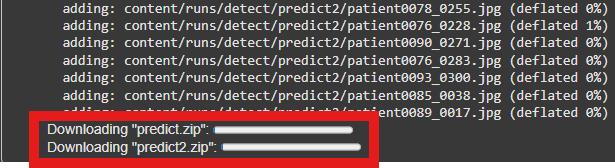

## 一些後處理嘗試

- 把重複框刪除因為第二個以後的匡都會變成FP扣分
 - run7_12x100e_AET_merged.txt                   lb0.9454
 - run7_12x100e_AET_merged_cleaned_first.txt     lb0.9373
 - run7_12x100e_AET_merged_cleaned_best-conf.txt lb0.9373
 - 測試後發現不刪除多餘的匡分數比較高！！且第一個就是最高信心所以兩個清理lb分數相同！！！

In [ ]:
# 保留 第一個 標註

def keep_first_one_txt()
    # 讀取 submission.txt 檔案
    lines = []
    with open('submission.txt', 'r') as f:
        for line in f:
            lines.append(line.strip())

    # 使用字典追蹤每個圖片的第一個標註
    seen = {}
    kept = []
    for line in lines:
        patient = line.split()[0]  # 圖片名稱在第一欄
        if patient not in seen:
            seen[patient] = True
            kept.append(line)
        # else: 後續重複的被忽略（刪除）

    # 計算刪除數量
    total_lines = len(lines)
    deleted = total_lines - len(kept)

    # 輸出統計
    print(f"刪除了 {deleted} 個 bounding boxes。")
    print(f"保留了 {len(kept)} 個唯一標註。")

    # 寫入清理後的檔案
    with open('cleaned_submission.txt', 'w') as f:
        for line in kept:
            f.write(line + '\n')

    print("已輸出 cleaned_submission.txt 檔案。")

In [12]:
# 保留 第一個 標註

import os

def keep_first_one_txt(input_path, output_path):
    """
    讀取輸入的 submission 檔案，對每個圖片（以第一欄名稱區分）
    只保留其第一個出現的標註（Bounding Box），並將結果寫入輸出檔案。

    Args:
        input_path (str): 輸入檔案 (e.g., 'submission.txt') 的路徑。
        output_path (str): 輸出檔案 (e.g., 'cleaned_submission.txt') 的路徑。
    """
    # 讀取輸入檔案
    lines = []
    try:
        with open(input_path, 'r') as f:
            for line in f:
                lines.append(line.strip())
        print(f"成功讀取檔案: {input_path}")
    except FileNotFoundError:
        print(f"錯誤：找不到檔案 {input_path}，請檢查路徑是否正確。")
        return
    except Exception as e:
        print(f"讀取檔案時發生錯誤: {e}")
        return

    # --- 核心邏輯：保留每個圖片的第一個標註 ---
    
    # 使用字典追蹤每個圖片的第一個標註
    seen = {}
    kept = []
    for line in lines:
        try:
            # 假設圖片名稱在第一欄，以空白字元分隔
            patient = line.split()[0]
        except IndexError:
            # 忽略空白行或格式不正確的行
            continue
            
        # 如果這是該圖片（patient）名稱第一次出現
        if patient not in seen:
            seen[patient] = True
            kept.append(line)
        # else: 後續重複的行將被忽略（刪除）

    # 計算統計
    total_lines = len(lines)
    deleted = total_lines - len(kept)

    # 輸出統計結果
    print("-" * 30)
    print(f"總行數 (原始標註數量): {total_lines}")
    print(f"刪除了重複的 bounding boxes: {deleted} 個")
    print(f"保留了唯一的標註 (每個圖片一個): {len(kept)} 個")
    print("-" * 30)

    # 寫入清理後的檔案
    try:
        with open(output_path, 'w') as f:
            for line in kept:
                f.write(line + '\n')
        print(f"已輸出清理後的檔案: {output_path}")
    except Exception as e:
        print(f"寫入檔案時發生錯誤: {e}")


# --- 範例使用方式 ---

# # 假設原始檔案在當前目錄下
# input_file = 'predict_txt/run7_12x100e_AET_merged.txt' 
# # 假設要輸出的檔案名稱
# output_file = 'predict_txt/run7_12x100e_AET_merged_cleaned_first.txt' 

# 假設原始檔案在當前目錄下
input_file = 'predict_txt/run8_12x100e_NET_merged.txt' 
# 假設要輸出的檔案名稱
output_file = 'predict_txt/run8_12x100e_NET_merged_cleaned_first.txt' 


# 執行函式
keep_first_one_txt(input_file, output_file)

成功讀取檔案: predict_txt/run8_12x100e_NET_merged.txt
------------------------------
總行數 (原始標註數量): 3834
刪除了重複的 bounding boxes: 391 個
保留了唯一的標註 (每個圖片一個): 3443 個
------------------------------
已輸出清理後的檔案: predict_txt/run8_12x100e_NET_merged_cleaned_first.txt


In [ ]:
成功讀取檔案: predict_txt/run7_12x100e_AET_merged.txt
------------------------------
總行數 (原始標註數量): 3170
刪除了重複的 bounding boxes: 276 個
保留了唯一的標註 (每個圖片一個): 2894 個
------------------------------
已輸出清理後的檔案: predict_txt/run7_12x100e_AET_merged_cleaned_first.txt

In [ ]:
# 保留信心指數最高的一個
# 讀取 submission.txt 檔案
lines = []
with open('submission.txt', 'r') as f:
    for line in f:
        lines.append(line.strip())

# 使用字典追蹤每個圖片的最佳標註 (最高 confidence)
seen = {}
kept = []
for line in lines:
    parts = line.split()
    patient = parts[0]  # 圖片名稱在第一欄
    conf = float(parts[2])  # 信心分數在第三欄
    if patient not in seen or conf > seen[patient]['conf']:
        seen[patient] = {'conf': conf, 'line': line}
        kept.append(line)
    # else: 保留原有或更高 conf 的，忽略較低者

# 計算刪除數量
total_lines = len(lines)
deleted = total_lines - len(kept)

# 輸出統計
print(f"刪除了 {deleted} 個 bounding boxes。")
print(f"保留了 {len(kept)} 個唯一標註。")

# 寫入清理後的檔案
with open('cleaned_submission.txt', 'w') as f:
    for line in kept:
        f.write(line + '\n')

print("已輸出 cleaned_submission.txt 檔案。")


In [11]:
# 保留信心指數最高的一個

import os

def keep_highest_confidence_txt(input_path, output_path):
    """
    讀取輸入的 submission 檔案，對每個圖片（以第一欄名稱區分），
    只保留其中信心指數（第三欄）最高的一個標註，並將結果寫入輸出檔案。

    Args:
        input_path (str): 輸入檔案 (e.g., 'submission.txt') 的路徑。
        output_path (str): 輸出檔案 (e.g., 'cleaned_submission.txt') 的路徑。
    """
    # 讀取輸入檔案
    lines = []
    try:
        with open(input_path, 'r') as f:
            for line in f:
                lines.append(line.strip())
        print(f"成功讀取檔案: {input_path}")
    except FileNotFoundError:
        print(f"錯誤：找不到檔案 {input_path}，請檢查路徑是否正確。")
        return
    except Exception as e:
        print(f"讀取檔案時發生錯誤: {e}")
        return

    # --- 核心邏輯：保留最高信心指數的標註 ---
    
    # 使用字典追蹤每個圖片的最佳標註 (最高 confidence)
    best_predictions = {}
    
    for line in lines:
        try:
            parts = line.split()
            patient = parts[0]     # 圖片名稱在第一欄
            # 將信心分數轉換為浮點數
            conf = float(parts[2]) # 信心分數在第三欄
        except (IndexError, ValueError):
            # 忽略格式不正確或欄位不足的行
            continue
            
        # 如果該圖片名稱是第一次出現，或當前的信心分數更高
        if patient not in best_predictions or conf > best_predictions[patient]['conf']:
            # 更新為當前最高的信心分數和對應的整行內容
            best_predictions[patient] = {'conf': conf, 'line': line}

    # 提取所有被選定的最佳標註行
    kept_lines = [item['line'] for item in best_predictions.values()]
    
    # 計算統計
    total_lines = len(lines)
    deleted = total_lines - len(kept_lines)

    # 輸出統計結果
    print("-" * 30)
    print(f"總行數 (原始標註數量): {total_lines}")
    print(f"刪除了重複且信心較低的 bounding boxes: {deleted} 個")
    print(f"保留了唯一的最佳標註 (每個圖片一個): {len(kept_lines)} 個")
    print("-" * 30)

    # 寫入清理後的檔案
    try:
        with open(output_path, 'w') as f:
            for line in kept_lines:
                f.write(line + '\n')
        print(f"已輸出清理後的檔案: {output_path}")
    except Exception as e:
        print(f"寫入檔案時發生錯誤: {e}")


# --- 範例使用方式 ---


# # 假設原始檔案在當前目錄下
# input_file = 'predict_txt/run7_12x100e_AET_merged.txt' 
# # 假設要輸出的檔案名稱
# output_file = 'predict_txt/run7_12x100e_AET_merged_cleaned_best-conf.txt' 

# 假設原始檔案在當前目錄下
input_file = 'predict_txt/run8_12x100e_NET_merged.txt' 
# 假設要輸出的檔案名稱
output_file = 'predict_txt/run8_12x100e_NET_merged_best-conf.txt' 

# 執行函式
keep_highest_confidence_txt(input_file, output_file)

成功讀取檔案: predict_txt/run8_12x100e_NET_merged.txt
------------------------------
總行數 (原始標註數量): 3834
刪除了重複且信心較低的 bounding boxes: 391 個
保留了唯一的最佳標註 (每個圖片一個): 3443 個
------------------------------
已輸出清理後的檔案: predict_txt/run8_12x100e_NET_merged_best-conf.txt


In [ ]:
成功讀取檔案: predict_txt/run7_12x100e_AET_merged.txt
------------------------------
總行數 (原始標註數量): 3170
刪除了重複且信心較低的 bounding boxes: 276 個
保留了唯一的最佳標註 (每個圖片一個): 2894 個
------------------------------
已輸出清理後的檔案: predict_txt/run7_12x100e_AET_merged_cleaned_best-conf.txt